<a href="https://colab.research.google.com/github/SamTremblay18/Hockey-Shot-Classification/blob/main/CNN_Method1_ALL_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Method 1 - Reframe to 576 frames and All Sensors Configuration

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from google.colab import drive
drive.mount('/content/drive')
import pickle
import matplotlib.pyplot as plt
from functools import partial
from tensorflow import keras
from collections import Counter
from keras import models
from keras import regularizers
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv1D, MaxPooling1D, Dropout, GlobalAveragePooling1D

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, f1_score

Mounted at /content/drive


In [ ]:
# install missing dependencies
!pip install keras-tuner
import keras_tuner as kt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.5 MB/s eta 0:00:00


In [ ]:
# load all data previously processed

def open_pickle(path_pickle):
  f = open(path_pickle, 'rb')
  P = pickle.load(f)
  f.close()
  return P

#X_train_all = open_pickle('/content/drive/MyDrive/Sam/File_saved/X_train_all1.pickle')
y_train_all = open_pickle('/content/drive/MyDrive/Sam/File_saved/y_train_all1.pickle')

#X_test1 = open_pickle('/content/drive/MyDrive/Sam/File_saved/X_test1.pickle')
X_train1 = open_pickle('/content/drive/MyDrive/Sam/File_saved/X_train1_1.pickle')
y_test1 = open_pickle('/content/drive/MyDrive/Sam/File_saved/y_test1.pickle')
y_train1 = open_pickle('/content/drive/MyDrive/Sam/File_saved/y_train1_1.pickle')
X_valid1 = open_pickle('/content/drive/MyDrive/Sam/File_saved/X_valid1_1.pickle')
y_valid1 = open_pickle('/content/drive/MyDrive/Sam/File_saved/y_valid1_1.pickle')

X_train2 = open_pickle('/content/drive/MyDrive/Sam/File_saved/X_train1_2.pickle')
y_train2 = open_pickle('/content/drive/MyDrive/Sam/File_saved/y_train1_2.pickle')
X_valid2 = open_pickle('/content/drive/MyDrive/Sam/File_saved/X_valid1_2.pickle')
y_valid2 = open_pickle('/content/drive/MyDrive/Sam/File_saved/y_valid1_2.pickle')

X_train3 = open_pickle('/content/drive/MyDrive/Sam/File_saved/X_train1_3.pickle')
y_train3 = open_pickle('/content/drive/MyDrive/Sam/File_saved/y_train1_3.pickle')
X_valid3 = open_pickle('/content/drive/MyDrive/Sam/File_saved/X_valid1_3.pickle')
y_valid3 = open_pickle('/content/drive/MyDrive/Sam/File_saved/y_valid1_3.pickle')

X_train4 = open_pickle('/content/drive/MyDrive/Sam/File_saved/X_train1_4.pickle')
y_train4 = open_pickle('/content/drive/MyDrive/Sam/File_saved/y_train1_4.pickle')
X_valid4 = open_pickle('/content/drive/MyDrive/Sam/File_saved/X_valid1_4.pickle')
y_valid4 = open_pickle('/content/drive/MyDrive/Sam/File_saved/y_valid1_4.pickle')

X_train5 = open_pickle('/content/drive/MyDrive/Sam/File_saved/X_train1_5.pickle')
y_train5 = open_pickle('/content/drive/MyDrive/Sam/File_saved/y_train1_5.pickle')
X_valid5 = open_pickle('/content/drive/MyDrive/Sam/File_saved/X_valid1_5.pickle')
y_valid5 = open_pickle('/content/drive/MyDrive/Sam/File_saved/y_valid1_5.pickle')

# Scaled train and test
X_train_all = open_pickle('/content/drive/MyDrive/Sam/File_saved/X_train_all1_sc.pickle')
X_test1     = open_pickle('/content/drive/MyDrive/Sam/File_saved/X_test1_sc.pickle')

In [ ]:
# check class weights
from sklearn.utils import class_weight
classes = np.unique(y_train_all)
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_all
)
class_weights = dict(zip(classes, weights))


# Normalize to percentages
total = sum(class_weights.values())
class_weights_percent = {cls: (w / total * 100) for cls, w in class_weights.items()}

# Print nicely
print("Class weights (as percentages):")
for cls, pct in class_weights_percent.items():
    print(f"Class {cls}: {pct:.2f}%")


from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_all, y_train_all, test_size=0.2, stratify=y_train_all, random_state=42
)

# class MacroF1Callback(keras.callbacks.Callback):
#     def __init__(self, x_valid, y_valid, name='val_macro_f1'):
#         super().__init__()
#         self.x_valid, self.y_valid, self.name = x_valid, y_valid, name
#     def on_epoch_end(self, epoch, logs=None):
#         y_prob = self.model.predict(self.x_valid, verbose=0)
#         y_pred = y_prob.argmax(axis=1)
#         score = f1_score(self.y_valid, y_pred, average='macro')
#         logs = logs or {}
#         logs[self.name] = score
#         # record in History so it's visible in history.history
#         self.model.history.history.setdefault(self.name, []).append(score)
#         print(f" — {self.name}: {score:.4f}")

Class weights (as percentages):
Class 0.0: 15.07%
Class 1.0: 14.87%
Class 2.0: 10.01%
Class 3.0: 30.03%
Class 4.0: 10.01%
Class 5.0: 10.03%
Class 6.0: 9.97%


# Trying a baseline model

Model based on Hfawaz https://keras.io/examples/timeseries/timeseries_classification_from_scratch/

Epoch 1/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 156ms/step - loss: 1.6844 - sparse_categorical_accuracy: 0.3274 - val_loss: 1.6920 - val_sparse_categorical_accuracy: 0.5000 - learning_rate: 3.0000e-04
Epoch 2/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.2190 - sparse_categorical_accuracy: 0.7193 - val_loss: 1.3516 - val_sparse_categorical_accuracy: 0.5057 - learning_rate: 3.0000e-04
Epoch 3/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.9926 - sparse_categorical_accuracy: 0.7802 - val_loss: 1.0592 - val_sparse_categorical_accuracy: 0.7254 - learning_rate: 3.0000e-04
Epoch 4/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.8591 - sparse_categorical_accuracy: 0.8080 - val_loss: 0.8764 - val_sparse_categorical_accuracy: 0.8163 - learning_rate: 3.0000e-04
Epoch 5/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.7546 - sparse_categorical_accuracy: 0.8561 - val_loss: 0.7395 - val_sparse_categorical_accuracy: 0.8561 - learning_rate: 3.0000e-04
Epoch 6/200
33/33 ━━━━━━━━━━

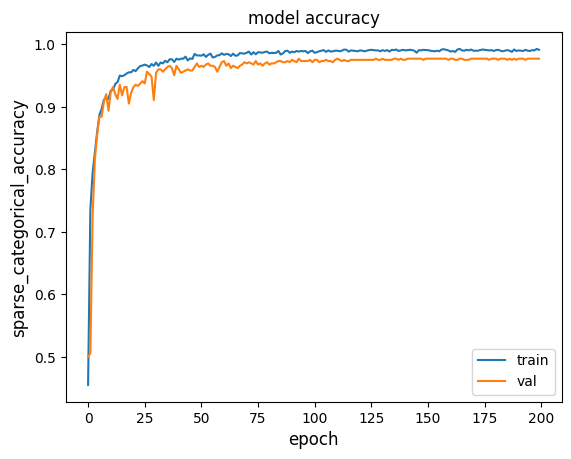

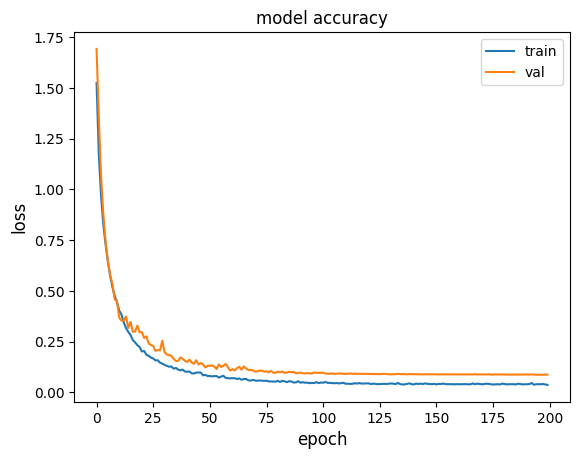

In [ ]:
def make_baseline_model(input_shape):
    input_layer = keras.layers.Input(input_shape)

    conv1 = keras.layers.Conv1D(filters=128, kernel_size=3, padding="same")(input_layer)
    conv1 = keras.layers.BatchNormalization()(conv1)
    conv1 = keras.layers.ReLU()(conv1)
    conv1 = keras.layers.Dropout(0.2)(conv1)

    conv2 = keras.layers.Conv1D(filters=128, kernel_size=3, padding="same")(conv1)
    conv2 = keras.layers.BatchNormalization()(conv2)
    conv2 = keras.layers.ReLU()(conv2)
    conv2 = keras.layers.Dropout(0.2)(conv2)

    conv3 = keras.layers.Conv1D(filters=128, kernel_size=3, kernel_regularizer=regularizers.l2(0.0001), padding="same")(conv2)
    conv3 = keras.layers.BatchNormalization()(conv3)
    conv3 = keras.layers.ReLU()(conv3)
    conv3 = keras.layers.Dropout(0.2)(conv3)

    gap = keras.layers.GlobalAveragePooling1D()(conv3)

    output_layer = keras.layers.Dense(7, activation="softmax")(gap)

    return keras.models.Model(inputs=input_layer, outputs=output_layer)

# clear any previous models/graphs
tf.keras.backend.clear_session()

# initialize baseline model model
model_baseline = make_baseline_model(input_shape=X_train_all.shape[1:])

loss = keras.losses.SparseCategoricalCrossentropy()
opt  = keras.optimizers.Adam(learning_rate=3e-4)

model_baseline.compile(
    optimizer=opt,
    loss=loss,
    metrics=['sparse_categorical_accuracy'])


ckpt_path = "checkpoints/baseline-best.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5),
]

history = model_baseline.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=200,
    callbacks=callbacks,
    validation_data= (X_valid, y_valid),
    verbose=1,
    class_weight=class_weights
)

# ALWAYS reload the checkpoint to avoid ending up with non-best weights
best_model = keras.models.load_model(ckpt_path)

# Evaluate on test
probs = best_model.predict(X_test1, verbose=0)
pred  = probs.argmax(axis=1)

print("Predicted class distribution:", np.bincount(pred, minlength=probs.shape[1]))
print("True class distribution     :", np.bincount(y_test1.astype(int), minlength=probs.shape[1]))

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test1, pred, digits=3))
cm = confusion_matrix(y_test1, pred, labels=np.arange(7), normalize='true')


plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history["val_sparse_categorical_accuracy"])
plt.title("model accuracy")
plt.ylabel('sparse_categorical_accuracy', fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()

plt.plot(history.history['loss'])
plt.plot(history.history["val_loss"])
plt.title("model accuracy")
plt.ylabel('loss', fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()

In [ ]:
def stats(X, name):
    mu = X.mean(axis=(0,1))   # (C,)
    sd = X.std(axis=(0,1))    # (C,)
    mn = X.min(axis=(0,1))
    mx = X.max(axis=(0,1))
    print(f"{name}: mean[:5]={mu[:5]}, std[:5]={sd[:5]}, min[:5]={mn[:5]}, max[:5]={mx[:5]}")

stats(X_train_all, "TRAIN")
stats(X_valid,     "VAL")
stats(X_test1,     "TEST")


TRAIN: mean[:5]=[-0.00430865 -0.00476146 -0.00523715 -0.04285418  0.00778541], std[:5]=[7.1268244 6.692837  3.0850978 9.134256  8.838146 ], min[:5]=[-812.1692  -520.394   -248.40077 -800.3241  -532.8167 ], max[:5]=[655.3449  584.26776 469.95483 728.63226 686.8806 ]
VAL: mean[:5]=[-0.00588673 -0.00636729 -0.00536882 -0.05906621  0.01331634], std[:5]=[7.0276165 6.719181  2.977179  9.059487  9.016267 ], min[:5]=[-739.0913  -493.50906 -166.80368 -730.8986  -521.45496], max[:5]=[546.7494   446.93     117.653984 570.9889   524.5154  ]
TEST: mean[:5]=[-0.00016657 -0.00148256 -0.0005421   0.00166706 -0.00614723], std[:5]=[0.893334   0.9033783  0.9263927  0.9062893  0.90705365], min[:5]=[-61.115738 -74.21169  -52.526424 -41.727093 -63.246586], max[:5]=[44.337414 35.460342 28.51063  39.50864  32.111526]


# Tuning model hyperparameters

In [ ]:
# load support functions
def _reg(choice, l=0.001):
    if choice == 'None': return None
    if choice == 'L1':
        return regularizers.l1(l)
    if choice == 'L2':
        return regularizers.l2(l)
    return regularizers.l1_l2(l1=l, l2=l)

In [ ]:
# Build model for tuning all folds
def build_model_tune(hp, input_shape):
    input_layer = keras.layers.Input(input_shape)

    reg1 = _reg(hp.Choice('regularizers1', ['None','L1','L2']))
    reg2 = _reg(hp.Choice('regularizers2', ['None','L1','L2']))
    reg3 = _reg(hp.Choice('regularizers3', ['None','L1','L2']))

    conv1 = keras.layers.Conv1D(
        filters=hp.Int('filters1', 64, 256, step=64),
        kernel_size=hp.Int('kernel_size1', 3, 5),
        kernel_regularizer=reg1,
        padding='same')(input_layer)
    conv1 = keras.layers.BatchNormalization()(conv1)
    conv1 = keras.layers.ReLU()(conv1)
    conv1 = keras.layers.Dropout(rate=hp.Float('dropout1', 0.0, 0.5, step=0.1))(conv1)

    conv2 = keras.layers.Conv1D(
        filters=hp.Int('filters2', 64, 256, step=64),
        kernel_size=hp.Int('kernel_size2', 3, 5),
        kernel_regularizer=reg2,
        padding='same')(conv1)                     # ← now stacked
    conv2 = keras.layers.BatchNormalization()(conv2)
    conv2 = keras.layers.ReLU()(conv2)            # ← uses conv2
    conv2 = keras.layers.Dropout(rate=hp.Float('dropout2', 0.0, 0.5, step=0.1))(conv2)

    conv3 = keras.layers.Conv1D(
        filters=hp.Int('filters3', 64, 256, step=64),
        kernel_size=hp.Int('kernel_size3', 3, 5),
        kernel_regularizer=reg3,
        padding='same')(conv2)
    conv3 = keras.layers.BatchNormalization()(conv3)
    conv3 = keras.layers.ReLU()(conv3)
    conv3 = keras.layers.Dropout(rate=hp.Float('dropout3', 0.0, 0.5, step=0.1))(conv3)

    gap = keras.layers.GlobalAveragePooling1D()(conv3)
    output_layer = keras.layers.Dense(7, activation='softmax')(gap)

    model = keras.Model(inputs=input_layer, outputs=output_layer)

    opt_name = hp.Choice('optimizer', ['adam','sgd','rmsprop'])
    opt = {'adam': keras.optimizers.Adam(3e-4),
           'sgd': keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9),
           'rmsprop': keras.optimizers.RMSprop(1e-3)}[opt_name]

    loss = keras.losses.SparseCategoricalCrossentropy()
    model.compile(optimizer=opt,
                  loss=loss,
                  metrics=['sparse_categorical_accuracy'])
    return model

## Tune all folds


In [ ]:
from keras_tuner import Objective
import os, random

SEED = 42

X_trains = [X_train1, X_train2, X_train3, X_train4, X_train5]
y_trains = [y_train1, y_train2, y_train3, y_train4, y_train5]
X_valids = [X_valid1, X_valid2, X_valid3, X_valid4, X_valid5]
y_valids = [y_valid1, y_valid2, y_valid3, y_valid4, y_valid5]

best_hps_per_fold = []
for i, (X_train, y_train, X_valid, y_valid) in enumerate(zip(X_trains, y_trains, X_valids, y_valids), start=1):

    # --- start each fold with a fresh TF graph & deterministic seeds ---
    tf.keras.backend.clear_session()
    os.environ["PYTHONHASHSEED"] = str(SEED)
    random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

    print(f"\n=== Running tuner for fold {i} ===")

    tuner = kt.RandomSearch(
        hypermodel=partial(build_model_tune, input_shape=X_train.shape[1:]),
        objective=Objective("val_loss", direction="min"),
        max_trials=50,
        executions_per_trial=1,
        overwrite=True,
        directory='random_search',
        project_name=f'all_sensors_fixed_fold{i}'
    )

 # per-fold callbacks (fresh each loop so they use that fold's val)
    fold_callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-5),
    ]

    tuner.search(
        X_train, y_train,
        epochs=200,
        validation_data=(X_valid, y_valid),
        class_weight=class_weights,           # ← important
        callbacks=fold_callbacks,
        verbose=1
    )

# save best hyperparameters for each fold
    best_hps = tuner.get_best_hyperparameters(1)[0]
    best_hps_per_fold.append(best_hps)

# Save best model per fold (not necessary)
# best_model = tuner.get_best_models(num_models=1)[0]
# best_model.save(f'best_model_fold{i}.h5')

Trial 50 Complete [00h 01m 22s]
val_loss: 0.27004510164260864

Best val_loss So Far: 0.12590400874614716
Total elapsed time: 01h 36m 17s


In [ ]:
# find best hyperparameters from list best_hps_per_fold

# List of hyperparameter names
int_params = ['filters1','filters2','filters3','kernel_size1','kernel_size2','kernel_size3']
float_params = ['dropout1','dropout2','dropout3']
categorical_params = ['regularizers1','regularizers2','regularizers3','optimizer']

final_params = {}

# Aggregate integer parameters by mean (rounded)
for param in int_params:
    values = [hp.get(param) for hp in best_hps_per_fold]
    final_params[param] = int(round(np.mean(values)))

# Aggregate float parameters by mean
for param in float_params:
    values = [hp.get(param) for hp in best_hps_per_fold]
    final_params[param] = float(np.mean(values))

# Aggregate categorical parameters by majority vote
for param in categorical_params:
    values = [hp.get(param) for hp in best_hps_per_fold]
    final_params[param] = Counter(values).most_common(1)[0][0]

print("Aggregated hyperparameters for final model:")
for k, v in final_params.items():
    print(f"{k}: {v}")



Aggregated hyperparameters for final model:
filters1: 243
filters2: 102
filters3: 192
kernel_size1: 4
kernel_size2: 4
kernel_size3: 5
dropout1: 0.18
dropout2: 0.14
dropout3: 0.16
regularizers1: L1
regularizers2: None
regularizers3: None
optimizer: rmsprop


In [ ]:
def build_final_model(X_train, params):
    input_layer = keras.layers.Input(X_train.shape[1:])

    reg1 = _reg(params['regularizers1'])
    reg2 = _reg(params['regularizers2'])
    reg3 = _reg(params['regularizers3'])

    conv1 = keras.layers.Conv1D(
        filters=params['filters1'],
        kernel_size=params['kernel_size1'],
        kernel_regularizer=reg1,
        padding='same')(input_layer)
    conv1 = keras.layers.BatchNormalization()(conv1)
    conv1 = keras.layers.ReLU()(conv1)
    conv1 = keras.layers.Dropout(rate=params['dropout1'])(conv1)

    conv2 = keras.layers.Conv1D(
        filters=params['filters2'],
        kernel_size=params['kernel_size2'],
        kernel_regularizer=reg2,
        padding='same')(conv1)
    conv2 = keras.layers.BatchNormalization()(conv2)
    conv2 = keras.layers.ReLU()(conv2)
    conv2 = keras.layers.Dropout(rate=params['dropout2'])(conv2)

    conv3 = keras.layers.Conv1D(
        filters=params['filters3'],
        kernel_size=params['kernel_size3'],
        kernel_regularizer=reg3,
        padding='same')(conv2)
    conv3 = keras.layers.BatchNormalization()(conv3)
    conv3 = keras.layers.ReLU()(conv3)
    conv3 = keras.layers.Dropout(rate=params['dropout3'])(conv3)

    gap = keras.layers.GlobalAveragePooling1D()(conv3)
    output_layer = keras.layers.Dense(7, activation='softmax')(gap)

    model = keras.Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=params['optimizer'],
                  loss='sparse_categorical_crossentropy',
                  metrics=['sparse_categorical_accuracy'])
    return model

#Cross-validation on final tuned model

In [ ]:
fold_accuracies = []
for i, (X_train, y_train, X_valid, y_valid) in enumerate(zip(X_trains, y_trains, X_valids, y_valids), start=1):
    tf.keras.backend.clear_session()
    print(f"\n=== Training final model on fold {i} ===")
    model = build_final_model(X_train, final_params)

    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-5),
    ]

    hist = model.fit(
        X_train, y_train,
        epochs=500, batch_size=64,
        validation_data=(X_valid, y_valid),
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

    vl, vacc = model.evaluate(X_valid, y_valid, verbose=0)
    print(f"Fold {i} - Val acc: {vacc:.4f}")
    fold_accuracies.append(vacc)

print(f"\nAverage Val acc across folds: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")


=== Training final model on fold 1 ===
Epoch 1/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 212ms/step - loss: 2.6166 - sparse_categorical_accuracy: 0.5605 - val_loss: 1.8442 - val_sparse_categorical_accuracy: 0.5500 - learning_rate: 0.0010
Epoch 2/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 1.2422 - sparse_categorical_accuracy: 0.8687 - val_loss: 1.6652 - val_sparse_categorical_accuracy: 0.5000 - learning_rate: 0.0010
Epoch 3/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.8140 - sparse_categorical_accuracy: 0.9076 - val_loss: 2.1262 - val_sparse_categorical_accuracy: 0.2618 - learning_rate: 0.0010
Epoch 4/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.6259 - sparse_categorical_accuracy: 0.9067 - val_loss: 2.5039 - val_sparse_categorical_accuracy: 0.2353 - learning_rate: 0.0010
Epoch 5/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.5081 - sparse_categorical_accuracy: 0.9269 - val_loss: 2.4511 - val_sparse_categorical_accuracy: 0.2824 - learning_rate: 0.0010
Epoch 6/

# Train tuned model on full dataset and evaluate on test set

Epoch 1/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 192ms/step - loss: 2.5728 - sparse_categorical_accuracy: 0.5634 - val_loss: 1.9137 - val_sparse_categorical_accuracy: 0.6780 - learning_rate: 0.0010
Epoch 2/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1.1941 - sparse_categorical_accuracy: 0.8694 - val_loss: 1.9684 - val_sparse_categorical_accuracy: 0.3523 - learning_rate: 0.0010
Epoch 3/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.7675 - sparse_categorical_accuracy: 0.9165 - val_loss: 2.2412 - val_sparse_categorical_accuracy: 0.2917 - learning_rate: 0.0010
Epoch 4/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.5663 - sparse_categorical_accuracy: 0.9258 - val_loss: 2.4128 - val_sparse_categorical_accuracy: 0.2803 - learning_rate: 0.0010
Epoch 5/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.4549 - sparse_categorical_accuracy: 0.9373 - val_loss: 1.9556 - val_sparse_categorical_accuracy: 0.3826 - learning_rate: 0.0010
Epoch 6/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/s

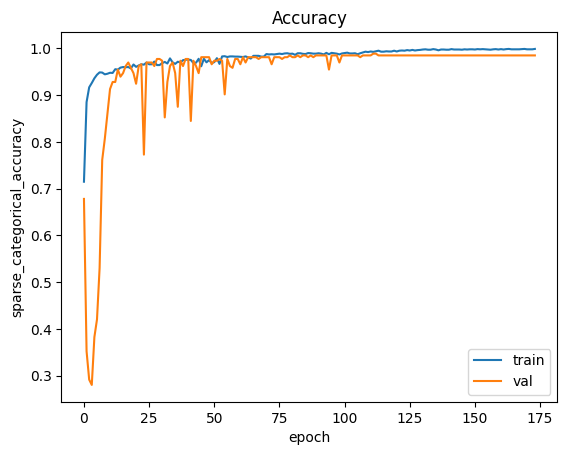

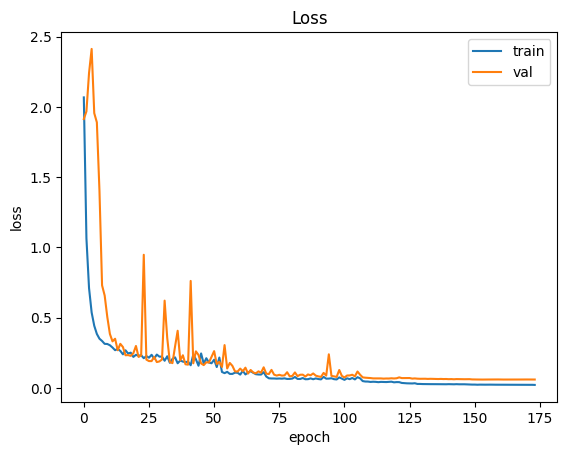

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_all, y_train_all, test_size=0.1, stratify=y_train_all, random_state=42
)

tf.keras.backend.clear_session()
model_final = build_final_model(X_train, final_params)

ckpt_path = 'checkpoints/final-best.keras'
final_callbacks = [
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-5),
]

history = model_final.fit(
    X_train, y_train,
    batch_size=64, epochs=500,
    validation_data=(X_valid, y_valid),
    class_weight=class_weights,
    callbacks=final_callbacks, verbose=1
)

best_model = keras.models.load_model(ckpt_path)

# Evaluate on test
probs = best_model.predict(X_test1, verbose=0)   # X_test1 is the *_scaled array
y_pred = probs.argmax(1)

print("Predicted class distribution:", np.bincount(y_pred, minlength=probs.shape[1]))
print("True class distribution     :", np.bincount(y_test1.astype(int), minlength=probs.shape[1]))
print(classification_report(y_test1, y_pred, digits=3))

plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.title("Accuracy")
plt.ylabel('sparse_categorical_accuracy'); plt.xlabel("epoch")
plt.legend(["train", "val"], loc="best"); plt.show(); plt.close()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.ylabel('loss'); plt.xlabel("epoch")
plt.legend(["train", "val"], loc="best"); plt.show(); plt.close()

Specificity per class:
BH: 1.000
OT: 1.000
Other: 0.993
Pass: 0.997
Rest: 0.993
SS: 1.000
WS: 0.996


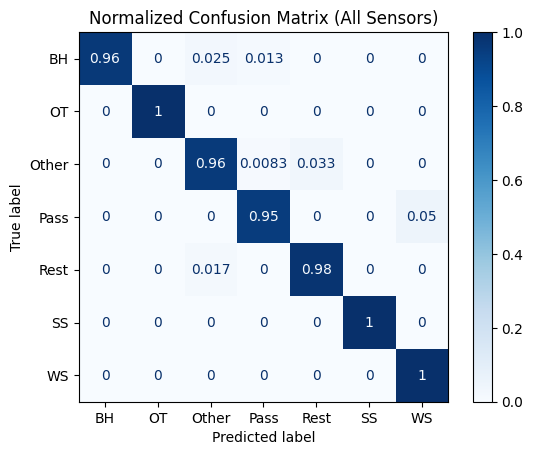

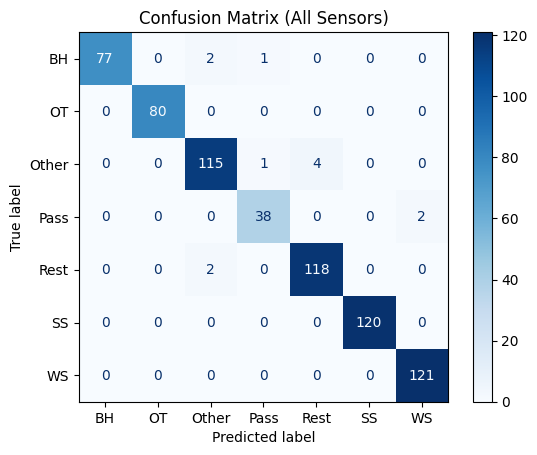

In [ ]:
cm = confusion_matrix(y_test1, y_pred, labels=np.arange(7))
FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)
TN = cm.sum() - (FP + FN + TP)
specificity = TN / (TN + FP + 1e-12)  # small eps

print("Specificity per class:")
labels = ["BH", "OT", "Other", "Pass", "Rest", "SS", "WS"]
for i, name in enumerate(labels):
    print(f"{name}: {specificity[i]:.3f}")

ConfusionMatrixDisplay.from_predictions(
    y_test1, y_pred, display_labels=labels, normalize='true', cmap=plt.cm.Blues
)
plt.title("Normalized Confusion Matrix (All Sensors)")
plt.show()

ConfusionMatrixDisplay.from_predictions(
    y_test1, y_pred, display_labels=labels, cmap=plt.cm.Blues
)
plt.title("Confusion Matrix (All Sensors)")
plt.show()
